<a href="https://colab.research.google.com/github/VictorNevola/ml-study/blob/main/ml_10_arvore_decis%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
def gini(n_pos, n_neg):
    total = n_pos + n_neg
    if total == 0:
        return 0.0
    p = n_pos / total
    return 1 - (p**2 + (1 - p)**2)

print(f"Group 50/50 (fully mixed): Gini = {gini(50, 50):.3f}  <- worst")
print(f"Group 90/10 (mostly one):  Gini = {gini(90, 10):.3f}")
print(f"Group 100/0 (pure):        Gini = {gini(100, 0):.3f}  <- best")

Group 50/50 (fully mixed): Gini = 0.500  <- worst
Group 90/10 (mostly one):  Gini = 0.180
Group 100/0 (pure):        Gini = 0.000  <- best


In [2]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("diabetes_en.csv")
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# which question is at the root?
root_feature = X.columns[tree.tree_.feature[0]]
root_threshold = tree.tree_.threshold[0]
root_gini = tree.tree_.impurity[0]

print(f"Root question: is '{root_feature}' <= {root_threshold:.1f} ?")
print(f"Gini at the root (before splitting): {root_gini:.3f}")

Root question: is 'glucose' <= 154.5 ?
Gini at the root (before splitting): 0.454


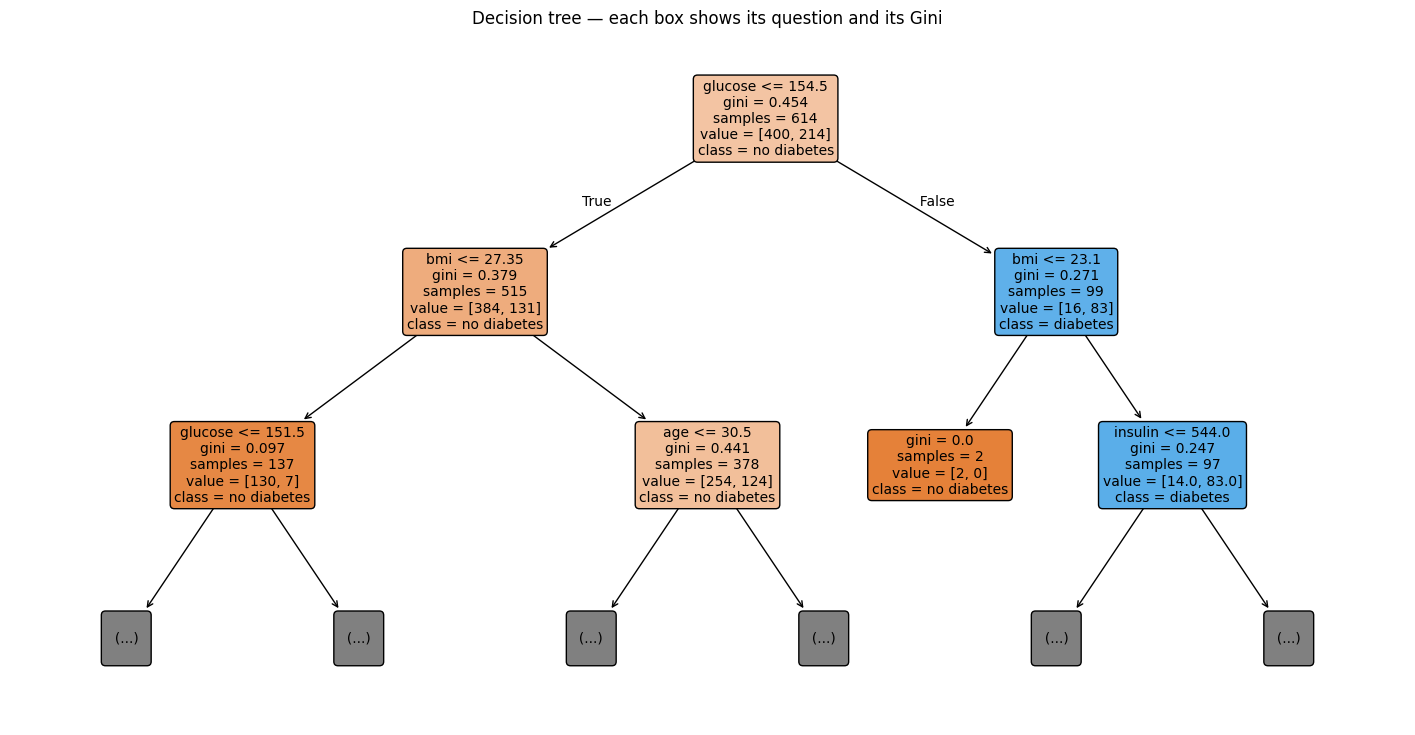

In [3]:

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(
    tree,
    max_depth=2,
    feature_names=list(X.columns),
    class_names=["no diabetes", "diabetes"],
    filled=True, rounded=True, fontsize=10, impurity=True, ax=ax
)
plt.title("Decision tree — each box shows its question and its Gini")
plt.show()

In [4]:

for depth in [1, 2, 3, 5, 8, None]:
    t = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    label = "None" if depth is None else depth
    print(f"max_depth={str(label):>4}  ->  train {t.score(X_train, y_train):.3f}  |  test {t.score(X_test, y_test):.3f}")

max_depth=   1  ->  train 0.761  |  test 0.695
max_depth=   2  ->  train 0.764  |  test 0.695
max_depth=   3  ->  train 0.767  |  test 0.695
max_depth=   5  ->  train 0.824  |  test 0.792
max_depth=   8  ->  train 0.914  |  test 0.753
max_depth=None  ->  train 1.000  |  test 0.727


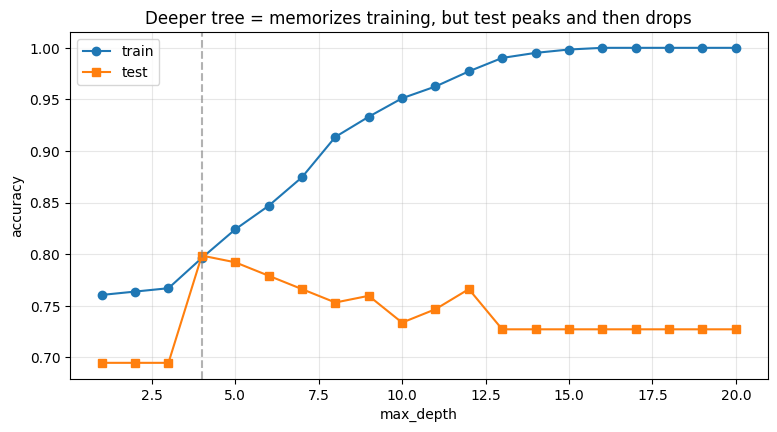

In [5]:

import numpy as np

depths = range(1, 21)
train_scores, test_scores = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_scores.append(t.score(X_train, y_train))
    test_scores.append(t.score(X_test, y_test))

plt.figure(figsize=(9, 4.5))
plt.plot(list(depths), train_scores, marker="o", label="train")
plt.plot(list(depths), test_scores, marker="s", label="test")
plt.axvline(list(depths)[int(np.argmax(test_scores))], color="gray", ls="--", alpha=0.6)
plt.xlabel("max_depth"); plt.ylabel("accuracy")
plt.title("Deeper tree = memorizes training, but test peaks and then drops")
plt.legend(); plt.grid(alpha=0.3)
plt.show()